Diego Toribio & Nolan Griffith   
Professor Krishna Karra  
ECE-471-A: Remote Sensing   
Final Project Proposal   

In [25]:
import ee
import geemap
from datetime import datetime, timedelta
import pandas as pd

ee.Authenticate
ee.Initialize(project='toribiodiego-ece471')

### Define Subset of Central Valley (Fresno)

In [22]:
# Define a small Central Valley subset (e.g. around Fresno)
roi = ee.Geometry.Rectangle(
    coords=[-122.5, 35.5, -119.5, 38.0],  # [west, south, east, north]
    proj='EPSG:4326',                      # WGS84
    geodesic=False
)

start_date = '2015-01-01'
end_date   = '2020-12-31'

print("ROI bounds:", roi.getInfo()['coordinates'])
print("Time span:", start_date, "to", end_date)

ROI bounds: [[[-122.5, 35.5], [-119.5, 35.5], [-119.5, 38], [-122.5, 38], [-122.5, 35.5]]]
Time span: 2015-01-01 to 2020-12-31


### Data Collection


We filtered each dataset’s image collection to the 2015–2020 period and our ROI. For example, the SMAP L4 collection is filtered to ~2015-01 through 2020-12 and clipped to the Central Valley subset. Similar filtering is done for MODIS GPP/ET and gridMET. The land cover is taken as a single year (2016) image for the ROI. The USDM data, if accessible, is filtered to get weekly drought classes in the region.

#### 3.1 SMAP L4 Soil Moisture

In [9]:
smap = (ee.ImageCollection("NASA/SMAP/SPL4SMGP/007")
          .filterDate(start_date, end_date)
          .filterBounds(roi)
          .select(['sm_surface', 'sm_rootzone'])
       )

# Verify count & date range
count = smap.size().getInfo()
first = smap.first().date().format('YYYY-MM-dd').getInfo()
last  = smap.sort('system:time_start', False).first().date().format('YYYY-MM-dd').getInfo()
bands = smap.first().bandNames().getInfo()

print(f"SMAP images: {count}")
print(f"  Date range: {first} → {last}")
print(f"  Bands: {bands}")

SMAP images: 16816
  Date range: 2015-03-31 → 2020-12-30
  Bands: ['sm_surface', 'sm_rootzone']


#### 3.2 MODIS GPP & ET

In [14]:
gpp = (
    ee.ImageCollection("UMT/NTSG/v2/MODIS/GPP")
      .filterDate(start_date, end_date)
      .filterBounds(roi)
      .select("GPP")
)
et = (
    ee.ImageCollection("MODIS/006/MOD16A2")
      .filterDate(start_date, end_date)
      .filterBounds(roi)
      .select("ET")
)

# Confirm GPP count and bands
gpp_count = gpp.size().getInfo()
if gpp_count > 0:
    gpp_bands = gpp.first().bandNames().getInfo()
else:
    gpp_bands = []
print(f"GPP count: {gpp_count}, Bands: {gpp_bands}")

# Confirm ET count and bands
et_count = et.size().getInfo()
if et_count > 0:
    et_bands = et.first().bandNames().getInfo()
else:
    et_bands = []
print(f"ET   count: {et_count}, Bands: {et_bands}")

GPP count: 276, Bands: ['GPP']
ET   count: 276, Bands: ['ET']


 #### 3.3 gridMET Meteorology

In [15]:
usdm = (ee.ImageCollection("projects/sat-io/open-datasets/us-drought-monitor")
          .filterDate(start_date, end_date)
          .filterBounds(roi)
       )

print("USDM count:", usdm.size().getInfo())
print("  Example bands:", usdm.first().bandNames().getInfo())

USDM count: 313
  Example bands: ['DM']


#### 3.4 US Drought Monitor

In [16]:
usdm = (ee.ImageCollection("projects/sat-io/open-datasets/us-drought-monitor")
          .filterDate(start_date, end_date)
          .filterBounds(roi)
       )

print("USDM count:", usdm.size().getInfo())
print("  Example bands:", usdm.first().bandNames().getInfo())

USDM count: 313
  Example bands: ['DM']


#### 3.5 MODIS Land Cover (2016)

In [17]:
landcover = (ee.ImageCollection("MODIS/061/MCD12Q1")
                .filterDate('2016-01-01', '2016-12-31')
                .first()
                .select('LC_Type1')
                .clip(roi)
            )

print("LC_Type1 projection:", landcover.projection().getInfo())
print("  Sample pixel values:", landcover.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=roi,
    scale=500
).getInfo())

LC_Type1 projection: {'type': 'Projection', 'crs': 'SR-ORG:6974', 'transform': [463.3127165279165, 0, -20015109.354, 0, -463.3127165279167, 10007554.677003]}
  Sample pixel values: {'LC_Type1': {'1': 9507.498039215685, '10': 81240.30588235281, '11': 614.8627450980392, '12': 68434.03529411765, '13': 15308.211764705886, '14': 510.4980392156863, '16': 354.5764705882353, '17': 56748.33725490189, '2': 3596.4823529411774, '4': 289.01176470588234, '5': 374.5254901960784, '6': 8123.627450980391, '7': 11730.321568627447, '8': 18339.71372549019, '9': 22021.25882352941}}


### 4. Preprocessing

#### 4.1 Weekly Aggregation

In [30]:
def weekly_collection(ic, start, end, agg='mean', band=None):
    """
    Split date range into weeks, reduce each slice, and return ImageCollection,
    skipping any weekly slice that has zero images.
    """
    start_dt = datetime.fromisoformat(start)
    end_dt   = datetime.fromisoformat(end)
    weeks = []
    curr = start_dt
    while curr < end_dt:
        next_dt = curr + timedelta(days=7)
        slice_ic = ic.filterDate(curr.isoformat(), next_dt.isoformat())
        count = slice_ic.size().getInfo()
        if count > 0:
            if band:
                slice_ic = slice_ic.select(band)
            img = getattr(slice_ic, agg)().set(
                'system:time_start',
                ee.Date(curr.isoformat()).millis()
            )
            weeks.append(img)
        else:
            print(f"Skipping week starting {curr.date()}: no images")
        curr = next_dt
    return ee.ImageCollection(weeks)

#### 4.2 Determine Common Start Time & Reproject to SMAP Grid

In [31]:
# 1) Find the first available date for each collection
collections = {
    'SMAP': smap,
    'GPP':  gpp,
    'ET':   et,
    'MET':  met,
    'USDM': usdm
}
first_dates = {}
for name, coll in collections.items():
    date_str = coll.first().date().format('YYYY-MM-dd').getInfo()
    first_dates[name] = datetime.fromisoformat(date_str)
print("First available dates:", first_dates)

# 2) Use the latest of those as your new weekly start to avoid empty weeks
start_valid = max(first_dates.values()).strftime('%Y-%m-%d')
print("Aggregating weekly from:", start_valid)

# 3) Re-create weekly composites from the common start date
smap_weekly    = weekly_collection(smap,  start_valid, end_date, agg='mean')
met_pr_weekly  = weekly_collection(met.select('pr'), start_valid, end_date, agg='sum')
met_t_weekly   = weekly_collection(met.select(['tmmn','tmmx']), start_valid, end_date, agg='mean')
gpp_weekly     = weekly_collection(gpp,  start_valid, end_date, agg='mean')
et_weekly      = weekly_collection(et,   start_valid, end_date, agg='mean')
usdm_weekly    = weekly_collection(usdm, start_valid, end_date, agg='mode')

# Confirm equal lengths
print("Weeks total:", smap_weekly.size().getInfo(),
      "SMAP:", smap_weekly.size().getInfo(),
      "Precip:", met_pr_weekly.size().getInfo(),
      "USDM:", usdm_weekly.size().getInfo())

# 4) Grab SMAP projection as reference
ref_proj = smap_weekly.first().projection()

# 5) Helper to reproject each image in a collection to SMAP’s grid
def reproject_ic(ic):
    return ic.map(lambda img: img.reproject(crs=ref_proj))

# 6) Apply reprojection
smap_w   = reproject_ic(smap_weekly)
met_pr_w = reproject_ic(met_pr_weekly)
met_t_w  = reproject_ic(met_t_weekly)
gpp_w    = reproject_ic(gpp_weekly)
et_w     = reproject_ic(et_weekly)
usdm_w   = reproject_ic(usdm_weekly)
lc_rp    = landcover.reproject(crs=ref_proj)  # static

# 7) Check a sample image — now guaranteed to have bands
sample = smap_w.first()
print("Reprojected SMAP band names:", sample.bandNames().getInfo())
print("CRS info:", sample.projection().getInfo()['crs'])

First available dates: {'SMAP': datetime.datetime(2015, 3, 31, 0, 0), 'GPP': datetime.datetime(2015, 1, 1, 0, 0), 'ET': datetime.datetime(2015, 1, 1, 0, 0), 'MET': datetime.datetime(2015, 1, 1, 0, 0), 'USDM': datetime.datetime(2015, 1, 6, 0, 0)}
Aggregating weekly from: 2015-03-31
Skipping week starting 2015-03-31: no images
Skipping week starting 2015-05-26: no images
Skipping week starting 2015-07-21: no images
Skipping week starting 2015-09-15: no images
Skipping week starting 2015-11-10: no images
Skipping week starting 2016-01-26: no images
Skipping week starting 2016-03-22: no images
Skipping week starting 2016-05-17: no images
Skipping week starting 2016-07-12: no images
Skipping week starting 2016-09-06: no images
Skipping week starting 2016-11-01: no images
Skipping week starting 2017-01-10: no images
Skipping week starting 2017-03-07: no images
Skipping week starting 2017-05-02: no images
Skipping week starting 2017-06-27: no images
Skipping week starting 2017-08-22: no image

#### 4.3 Sample & Export to Python for Verification

Sample point (lon, lat): [-121.0, 36.75]
            sm_surface  sm_rootzone        pr        tmmn        tmmx    GPP  \
date                                                                           
2015-03-31    0.128823     0.192316  0.000000  280.855499  294.875854    NaN   
2015-04-07    0.172590     0.198059  8.632795  281.910980  295.432098  370.0   
2015-04-14    0.126230     0.190258  0.000000  283.768188  299.343353  373.0   
2015-04-21    0.151147     0.189499  3.720681  284.084961  296.997131  372.0   
2015-04-28    0.133461     0.189911  0.000000  287.054474  302.740234  426.0   

              ET   DM  
date                   
2015-03-31   NaN  4.0  
2015-04-07  67.0  4.0  
2015-04-14  71.0  4.0  
2015-04-21  76.0  4.0  
2015-04-28  72.0  4.0  


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

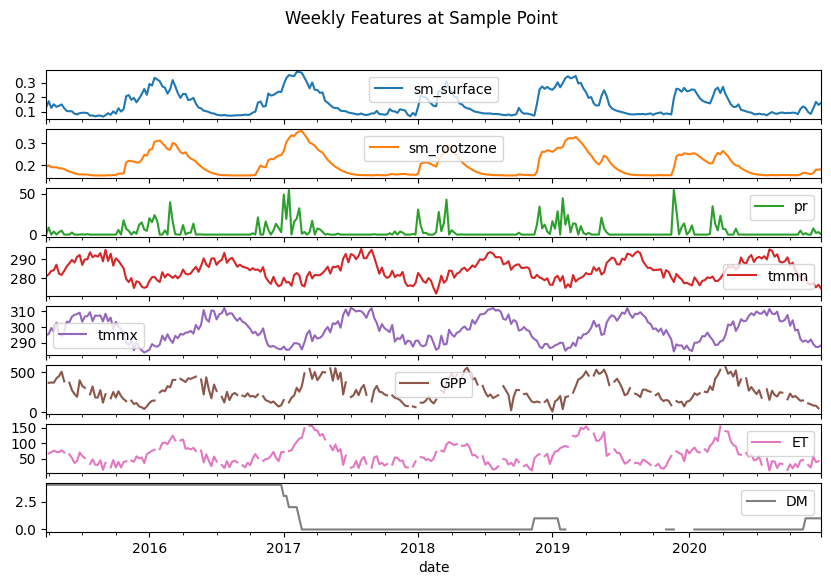

In [32]:
import pandas as pd

# Compute centroid in Python
coords = roi.getInfo()['coordinates'][0]
lons, lats = [pt[0] for pt in coords], [pt[1] for pt in coords]
centroid = [(min(lons)+max(lons))/2, (min(lats)+max(lats))/2]
print("Sample point (lon, lat):", centroid)

def extract_timeseries(ic, band_name, scale=9000):
    arr = ic.getRegion(ee.Geometry.Point(centroid), scale).getInfo()
    df = pd.DataFrame(arr[1:], columns=arr[0])
    df['date'] = pd.to_datetime(df['time'], unit='ms')
    if band_name not in df:
        raise KeyError(f"Band '{band_name}' missing; available: {df.columns.tolist()}")
    return df[['date', band_name]].set_index('date')

# Pull each weekly collection at the centroid
df_sm_surf = extract_timeseries(smap_w.select('sm_surface'), 'sm_surface')
df_sm_root = extract_timeseries(smap_w.select('sm_rootzone'), 'sm_rootzone')
df_pr      = extract_timeseries(met_pr_w.select('pr'),          'pr')
df_tmn     = extract_timeseries(met_t_w.select('tmmn'),        'tmmn')
df_tmx     = extract_timeseries(met_t_w.select('tmmx'),        'tmmx')
df_gpp     = extract_timeseries(gpp_w.select('GPP'),           'GPP')
df_et      = extract_timeseries(et_w.select('ET'),             'ET')
df_dm      = extract_timeseries(usdm_w.select('DM'),           'DM')

# Combine into one DataFrame
df = pd.concat([
    df_sm_surf, df_sm_root, df_pr,
    df_tmn, df_tmx, df_gpp,
    df_et, df_dm
], axis=1)

print(df.head())
df.plot(subplots=True, figsize=(10,6), title="Weekly Features at Sample Point")

#### 4.4 Normalize & Assemble Feature Matrix

In [35]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1) Drop any rows with NaNs and .copy() to avoid SettingWithCopyWarning
df_clean = df.dropna().copy()
print("Weeks remaining after dropna:", len(df_clean))

# 2) Scale DM from [0..5] → [0..1]
df_clean.loc[:, 'DM'] = df_clean['DM'] / 5.0

# 3) Add previous-week DM as a feature (autoregression) using .bfill()
df_clean.loc[:, 'DM_prev'] = df_clean['DM'].shift(1).bfill()

# 4) Select feature columns and target
feature_cols = ['sm_surface','sm_rootzone','pr','tmmn','tmmx','GPP','ET','DM_prev']
X_all = df_clean[feature_cols].values    # shape = (T, 8)
y_all = df_clean['DM'].values            # shape = (T,)

# 5) Standardize continuous inputs (mean=0, std=1)
means = X_all.mean(axis=0)
stds  = X_all.std(axis=0)
X_norm = (X_all - means) / stds

# 6) Build sequences: 8-week encoder → 4-week decoder
ENC_LEN, DEC_LEN = 8, 4
Xs, Ys = [], []
for i in range(len(X_norm) - ENC_LEN - DEC_LEN + 1):
    Xs.append(X_norm[i : i+ENC_LEN])
    Ys.append(y_all[i+ENC_LEN : i+ENC_LEN+DEC_LEN])
Xs = np.stack(Xs)               # (N_samples, 8, 8)
Ys = np.stack(Ys)[...,None]     # (N_samples, 4, 1)
print("Sequence shapes → X:", Xs.shape, "Y:", Ys.shape)

# 7) Convert to PyTorch tensors & DataLoader
X_tensor = torch.from_numpy(Xs).float()
Y_tensor = torch.from_numpy(Ys).float()
dataset  = TensorDataset(X_tensor, Y_tensor)
loader   = DataLoader(dataset, batch_size=16, shuffle=True)

Weeks remaining after dropna: 223
Sequence shapes → X: (212, 8, 8) Y: (212, 4, 1)


### 4. Training & Preliminary Results

### DroughtCast Seq2Seq model

In [40]:
import torch
import torch.nn as nn

class DroughtCastModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, encoder_layers=1):
        super().__init__()
        # 1) Input preprocessing
        self.input_net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(), nn.BatchNorm1d(hidden_size), nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(), nn.BatchNorm1d(hidden_size), nn.Dropout(0.2)
        )
        # 2) Encoder GRU
        self.encoder = nn.GRU(
            hidden_size, hidden_size,
            num_layers=encoder_layers,
            batch_first=True
        )
        # 3) Decoder cell
        self.decoder_cell = nn.GRUCell(hidden_size, hidden_size)
        # 4) Project scalar output back to hidden_size for next step
        self.decoder_input_proj = nn.Linear(output_size, hidden_size)
        # 5) Output network
        self.output_net = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(), nn.BatchNorm1d(hidden_size), nn.Dropout(0.2),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, X_encoder, target_length):
        batch_size = X_encoder.size(0)
        # Preprocess inputs
        X_flat = X_encoder.reshape(-1, X_encoder.size(-1))
        X_hid  = self.input_net(X_flat)
        X_hid  = X_hid.view(batch_size, -1, X_hid.size(-1))
        # Encode
        _, hid = self.encoder(X_hid)
        hidden_state = hid[-1]  # (batch, hidden)

        # Initialize decoder input as zeros in hidden space
        dec_input = torch.zeros(batch_size, hidden_state.size(-1), device=X_encoder.device)

        outputs = []
        for _ in range(target_length):
            # One GRUCell step
            hidden_state = self.decoder_cell(dec_input, hidden_state)
            out = self.output_net(hidden_state)        # (batch, 1)
            outputs.append(out)
            # Project output back up to hidden_size
            dec_input = self.decoder_input_proj(out)

        return torch.stack(outputs, dim=1)  # shape (batch, target_length, output_size)

model = DroughtCastModel(
    input_size=train_X.shape[2],
    hidden_size=64,
    output_size=1
)

#### 4.1 Train/Test Split & DataLoaders

In [42]:
from torch.utils.data import TensorDataset, DataLoader

# assuming X_tensor, Y_tensor, ENC_LEN, DEC_LEN are already defined
num_samples = X_tensor.shape[0]
train_size = int(0.8 * num_samples)

# Split into train / test
train_X = X_tensor[:train_size]
train_Y = Y_tensor[:train_size]
test_X  = X_tensor[train_size:]
test_Y  = Y_tensor[train_size:]

# Build DataLoaders
train_loader = DataLoader(
    TensorDataset(train_X, train_Y),
    batch_size=16,
    shuffle=True
)
test_loader = DataLoader(
    TensorDataset(test_X, test_Y),
    batch_size=len(test_X),
    shuffle=False
)

print(f"Train samples: {len(train_X)}, Test samples: {len(test_X)}")

Train samples: 169, Test samples: 43


#### 4.2 Training Loop

In [43]:
import torch.nn as nn
import torch.optim as optim

# 1) Instantiate model, loss, optimizer
model     = DroughtCastModel(input_size=train_X.shape[2], hidden_size=64, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 2) Train for 10 epochs
epochs = 10
for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        # forward pass: predict DEC_LEN weeks ahead
        pred = model(xb, DEC_LEN).squeeze(-1)         # shape: (batch, DEC_LEN)
        loss = criterion(pred, yb.squeeze(-1))       # compare to (batch, DEC_LEN)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch}/{epochs} — Training MSE: {avg_loss:.4f}")

Epoch 1/10 — Training MSE: 0.3012
Epoch 2/10 — Training MSE: 0.2351
Epoch 3/10 — Training MSE: 0.1649
Epoch 4/10 — Training MSE: 0.1361
Epoch 5/10 — Training MSE: 0.1077
Epoch 6/10 — Training MSE: 0.1050
Epoch 7/10 — Training MSE: 0.0740
Epoch 8/10 — Training MSE: 0.0788
Epoch 9/10 — Training MSE: 0.0628
Epoch 10/10 — Training MSE: 0.0583


#### 4.3 Evaluation & Plotting

In [45]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

model.eval()
with torch.no_grad():
    # full-batch test since test_loader batch_size = len(test)
    xb_test, yb_test = next(iter(test_loader))
    preds = model(xb_test, DEC_LEN).squeeze(-1).cpu().numpy().ravel()
    truths = yb_test.squeeze(-1).cpu().numpy().ravel()

# Clip predictions to [0,1]
preds_clipped = np.clip(preds, 0.0, 1.0)

mse_test = mean_squared_error(truths, preds_clipped)
r2_test  = r2_score(truths, preds_clipped)

print(f"Test  MSE: {mse_test:.4f}   (RMSE ≈ {np.sqrt(mse_test):.3f})")
print(f"Test  R²:  {r2_test:.3f}")

Test  MSE: 0.0063   (RMSE ≈ 0.080)
Test  R²:  -1.119


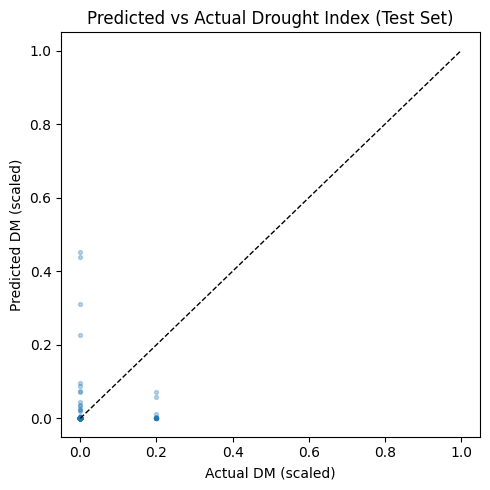

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(truths, preds_clipped, alpha=0.3, s=8)
plt.plot([0,1], [0,1], 'k--', linewidth=1)  # 1:1 line
plt.xlabel("Actual DM (scaled)")
plt.ylabel("Predicted DM (scaled)")
plt.title("Predicted vs Actual Drought Index (Test Set)")
plt.tight_layout()
plt.show()